In [ ]:
# STEP 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [ ]:
# STEP 2: Load and preprocess data
df = pd.read_csv('weather_data.csv')

# Combine date and time
df['DATETIME'] = pd.to_datetime(df['DATE'] + ' ' + df['TIME(UTC)'], format="%d-%m-%Y %H:%M:%S")
df.drop(columns=['DATE', 'TIME(UTC)'], inplace=True)
df.set_index('DATETIME', inplace=True)
df = df.sort_index()


In [ ]:
# STEP 3: Scale data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)
FEATURE_COLS = df.columns.tolist()
TARGET_COL = 'TEMP(C)'
temp_index = FEATURE_COLS.index(TARGET_COL)


In [ ]:
# STEP 4: Create sequences
LOOKBACK = 96  # 1 day (96 x 15min)
PREDICT_FORWARD = 672  # 7 days
X, y = [], []

for i in range(LOOKBACK, len(scaled_data) - PREDICT_FORWARD):
    X.append(scaled_data[i - LOOKBACK:i])
    y.append(scaled_data[i:i + PREDICT_FORWARD, temp_index])

X, y = np.array(X), np.array(y)

In [ ]:
# STEP 5: Train-test split
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]


In [ ]:
# STEP 6: Build LSTM model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    LSTM(32),
    Dense(PREDICT_FORWARD)  # Predict 672 future values (1 week)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 96, 64)         │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 672)            │        22,176 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,560 (213.12 KB)

 Trainable params: 54,560 (213.12 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# STEP 7: Train model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

Epoch 1/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 18s 87ms/step - loss: 0.1089 - val_loss: 0.0587
Epoch 2/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 14s 86ms/step - loss: 0.0290 - val_loss: 0.0120
Epoch 3/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 21s 88ms/step - loss: 0.0070 - val_loss: 0.0114
Epoch 4/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 21s 89ms/step - loss: 0.0056 - val_loss: 0.0097
Epoch 5/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 20s 89ms/step - loss: 0.0047 - val_loss: 0.0093
Epoch 6/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 22s 95ms/step - loss: 0.0044 - val_loss: 0.0103
Epoch 7/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 15s 91ms/step - loss: 0.0042 - val_loss: 0.0092
Epoch 8/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 14s 88ms/step - loss: 0.0040 - val_loss: 0.0075
Epoch 9/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - loss: 0.0039 - val_loss: 0.0081
Epoch 10/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 19s 86ms/step - loss: 0.0038 - val_loss: 0.0095


In [ ]:
# STEP 8: Predict on test data
pred_scaled = model.predict(X_test[-1].reshape(1, LOOKBACK, X.shape[2]))
pred_temp = scaler.inverse_transform(
    np.concatenate([
        np.zeros((PREDICT_FORWARD, X.shape[2])),  # Dummy features
    ], axis=1)
)
pred_temp[:, temp_index] = pred_scaled[0]
final_predictions = scaler.inverse_transform(pred_temp)[:, temp_index]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step


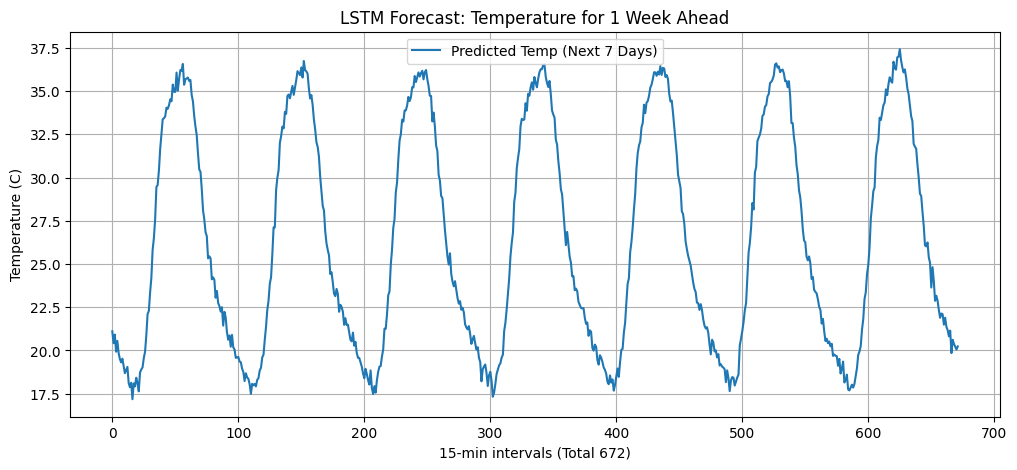

In [ ]:
# STEP 9: Plot results
plt.figure(figsize=(12, 5))
plt.plot(final_predictions, label="Predicted Temp (Next 7 Days)")
plt.title("LSTM Forecast: Temperature for 1 Week Ahead")
plt.xlabel("15-min intervals (Total 672)")
plt.ylabel("Temperature (C)")
plt.legend()
plt.grid(True)
plt.show()

<ipython-input-22-6ad66bdba288>:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  future_timestamps = pd.date_range(start="2025-03-27 00:15:00", periods=PREDICT_FORWARD, freq='15T')


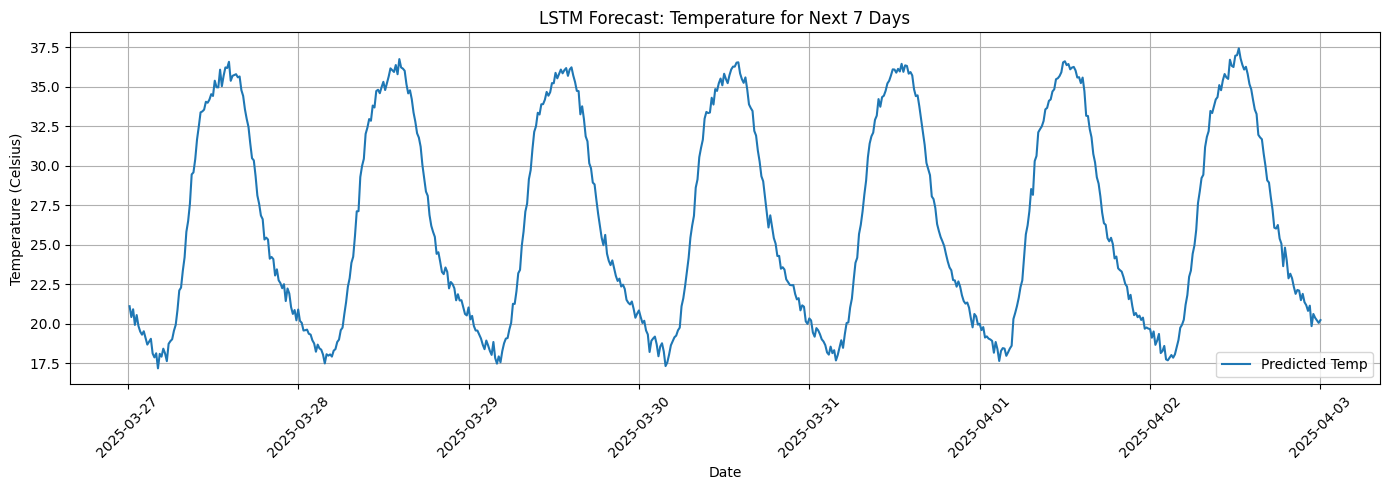

,Predicted_TEMP(C)
DATETIME,
2025-03-27 00:15:00,21.109620
2025-03-27 00:30:00,20.420769
2025-03-27 00:45:00,20.915037
2025-03-27 01:00:00,19.927448
2025-03-27 01:15:00,20.551630


In [ ]:
# STEP 8b: Generate future timestamps from "27-03-2025 00:15:00"
future_timestamps = pd.date_range(start="2025-03-27 00:15:00", periods=PREDICT_FORWARD, freq='15T')

# STEP 8c: Create DataFrame with predictions and timestamps
forecast_df = pd.DataFrame({
    'DATETIME': future_timestamps,
    'Predicted_TEMP(C)': final_predictions
})
forecast_df.set_index('DATETIME', inplace=True)

# STEP 9: Plot predicted temperature with timestamps
plt.figure(figsize=(14, 5))
plt.plot(forecast_df.index, forecast_df['Predicted_TEMP(C)'], label="Predicted Temp")
plt.title("LSTM Forecast: Temperature for Next 7 Days")
plt.xlabel("Date")
plt.ylabel("Temperature (Celsius)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Optional: Display first few predictions
forecast_df.head()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


<ipython-input-23-d980c8fa4164>:30: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  future_times = pd.date_range(start=loop_start, periods=PREDICT_FORWARD, freq="15T")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


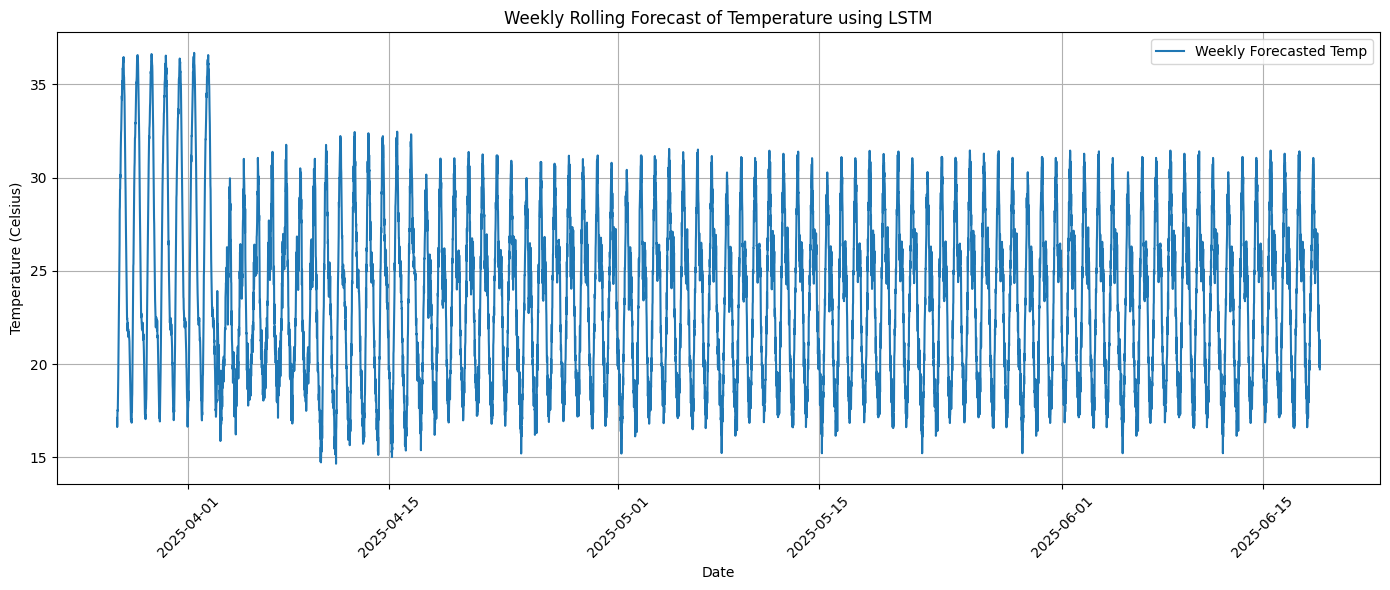

,Predicted_TEMP(C)
DATETIME,
2025-06-18 23:00:00,20.982771
2025-06-18 23:15:00,19.836791
2025-06-18 23:30:00,21.307061
2025-06-18 23:45:00,20.405423
2025-06-19 00:00:00,19.722327


In [ ]:
from datetime import datetime, timedelta

# PARAMETERS
loop_start = pd.Timestamp("2025-03-27 00:15:00")
loop_end = pd.Timestamp("2025-06-15 00:00:00")  # Replace with datetime.today() if you want real-time end

# Start with original scaled data
forecast_data = scaled_data.copy()
forecast_dates = df.index.tolist()

# Store all predictions
all_predictions = []

while loop_start <= loop_end:
    # Get the last LOOKBACK values
    recent_data = forecast_data[-LOOKBACK:]
    input_seq = np.expand_dims(recent_data, axis=0)  # Shape (1, 96, features)

    # Predict next week
    pred_scaled = model.predict(input_seq)[0]

    # Reconstruct full feature matrix with only predicted TEMP(C) updated
    future_block = np.zeros((PREDICT_FORWARD, forecast_data.shape[1]))
    future_block[:, temp_index] = pred_scaled

    # Append predictions to forecast_data
    forecast_data = np.vstack([forecast_data, future_block])

    # Generate corresponding future timestamps
    future_times = pd.date_range(start=loop_start, periods=PREDICT_FORWARD, freq="15T")
    forecast_dates.extend(future_times)

    # Save prediction
    all_predictions.extend(pred_scaled)

    # Advance time
    loop_start += timedelta(days=7)

# Create final DataFrame with all predicted temps
pred_temp_values = np.zeros((len(all_predictions), forecast_data.shape[1]))
pred_temp_values[:, temp_index] = all_predictions
final_temp_values = scaler.inverse_transform(pred_temp_values)[:, temp_index]

# Combine with datetime
full_forecast_df = pd.DataFrame({
    'DATETIME': forecast_dates[-len(final_temp_values):],
    'Predicted_TEMP(C)': final_temp_values
})
full_forecast_df.set_index('DATETIME', inplace=True)

# Plot the full forecast
plt.figure(figsize=(14, 6))
plt.plot(full_forecast_df.index, full_forecast_df['Predicted_TEMP(C)'], label='Weekly Forecasted Temp')
plt.title('Weekly Rolling Forecast of Temperature using LSTM')
plt.xlabel('Date')
plt.ylabel('Temperature (Celsius)')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Preview final few predictions
full_forecast_df.tail()


In [ ]:
# Save predictions to CSV
full_forecast_df.to_csv("LSTM_Temperature_Predictions_Till_2025_06_05.csv")
from google.colab import files
files.download("LSTM_Temperature_Predictions_Till_2025_06_05.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>